In [1]:
import warnings
warnings.filterwarnings("ignore")
import muon as mu
import numpy as np
import scanpy as sc
import scirpy as ir
from cycler import cycler
from matplotlib import cm as mpl_cm
from matplotlib import pyplot as plt
from mudata import MuData
sc.set_figure_params(figsize=(4, 4))
sc.settings.verbosity = 2  # verbosity: errors (0), warnings (1), info (2), hints (3)

2026-03-09 21:12:54.729013: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-09 21:12:54.729250: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-09 21:12:54.755796: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-09 21:12:56.454297: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different compu

## Importing data

In [2]:
path = "/ix1/ylee/Yifan_Zhang/CellRanger_tests/E1P/outs/"

In [8]:
# Load the associated transcriptomics data
mdata = mu.read_10x_h5(path + "filtered_feature_bc_matrix.h5")
mdata

reading /ix1/ylee/Yifan_Zhang/CellRanger_tests/E1P/outs/filtered_feature_bc_matrix.h5
 (0:00:00)


MuData object with n_obs × n_vars = 2512 × 33696
  var:	'gene_ids', 'feature_types', 'genome'
  1 modality
    rna:	2512 x 33696
      var:	'gene_ids', 'feature_types', 'genome'

In [ ]:
mdata_raw = mu.read_10x_h5(path + "raw_feature_bc_matrix.h5")
mdata_raw

# pre-processing

In [4]:
import matplotlib.pyplot as plt
import numpy as np

In [5]:
sc.pp.log1p(mdata["gex"])
sc.pp.pca(mdata["gex"], svd_solver="arpack")
sc.pp.neighbors(mdata["gex"])
sc.tl.umap(mdata["gex"])

computing PCA
    with n_comps=50
    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished (0:00:00)
computing UMAP
    finished (0:00:01)


In [6]:
# what can be used as 'color'
print(mdata.var_names)
print(mdata.obs.columns)

Index(['Xkr4', 'Gm1992', 'Gm19938', 'Gm37381', 'Rp1', 'Sox17', 'Gm37587',
       'Gm37323', 'Mrpl15', 'A930006A01Rik',
       ...
       'Gm16367', 'ENSMUSG00000094172', 'ENSMUSG00000094887',
       'ENSMUSG00000091585', 'ENSMUSG00000095763', 'ENSMUSG00000095523',
       'ENSMUSG00000095475', 'ENSMUSG00000094855', 'ENSMUSG00000095019',
       'ENSMUSG00000095041'],
      dtype='object', length=33696)
Index([], dtype='object')


InvalidIndexError: Reindexing only valid with uniquely valued Index objects

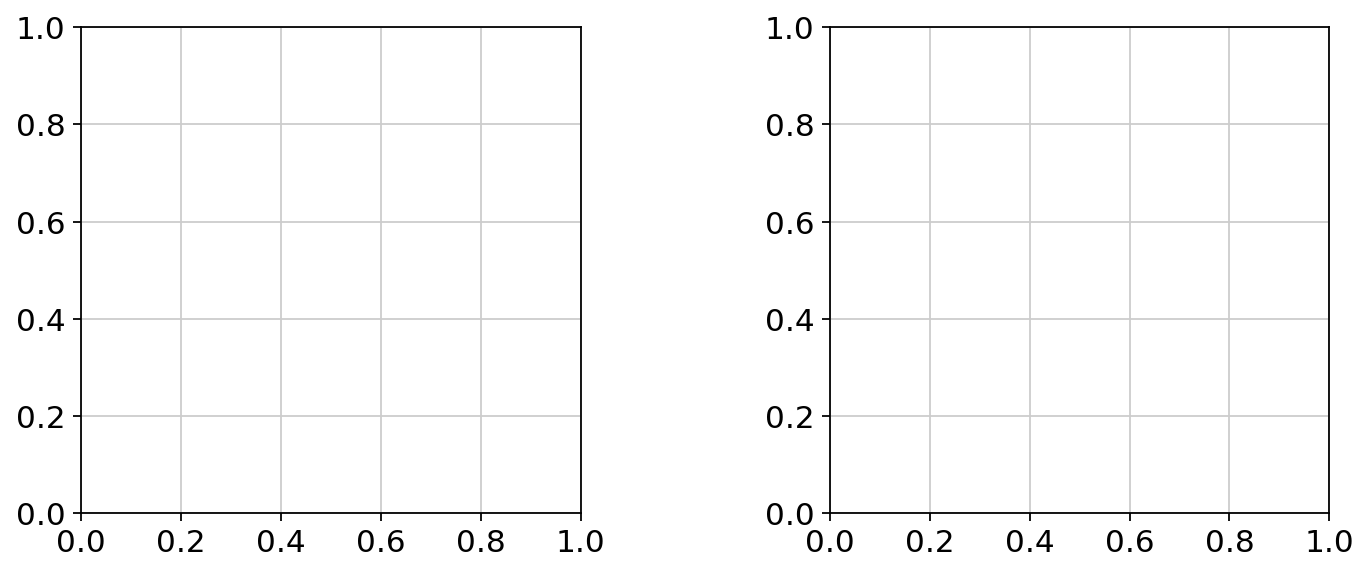

In [7]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={"wspace": 0.5})
mu.pl.embedding(mdata, basis="gex:umap", color=["Cd3e"], ax=ax0, show=False)
mu.pl.embedding(mdata, basis="gex:umap", color=["airr:receptor_type"], ax=ax1)

In [ ]:
mu.pl.embedding(mdata, basis="gex:umap", color=['manual_cell_type','gex:tissue'],wspace = 0.5)

In [ ]:
# mdata_new.write("common_GEX_TCR_mdata.h5mu")

# save filtered TCR table

In [ ]:
mdata = mu.read("common_GEX_TCR_mdata.h5mu")
mdata

In [ ]:
adata_tcr = mdata.mod['airr']
adata_tcr.obsm["airr"][0]

In [ ]:
meta_DF = ir.get.airr(adata_tcr, ["cdr3_aa", "consensus_count", "v_call", "j_call"] ,  ('VJ_1', 'VDJ_1'))

# , "high_confidence","productive"

# ('VJ_1', 'VDJ_1', 'VJ_2', 'VDJ_2'), 

meta_DF.iloc[0:10,:]

In [ ]:
meta_DF["VJ_1_v_call"].value_counts()

In [ ]:
meta_DF.to_csv('primary_TCR.csv', index=True)